# 🛣️ IDD20k II — YOLOv8m-seg Fine-tuning Pipeline
**Indian Road Object Detection + Instance Segmentation + Drivable Area**

| | |
|---|---|
| Model | `yolov8m-seg.pt` (COCO pretrained) |
| Dataset | IDD20k II (37 fine-grained labels) |
| GPU | RTX 4050 6 GB (auto-configured) |
| Drivable area | Binary class merged from `road`, `parking`, `drivable fallback` |

---
### Run order
1. **Cell 1** — Install dependencies  
2. **Cell 2** — Imports & global config  
3. **Cell 3** — Dataset preparation (IDD → YOLO format)  
4. **Cell 4** — Training  
5. **Cell 5** — Evaluation & metrics  
6. **Cell 6** — Inference / demo  

---
## Cell 1 — Install Dependencies

In [ ]:
# ── Install all required packages ───────────────────────────────────────────
# Run once. Restart kernel after this cell if packages were freshly installed.

import subprocess, sys

packages = [
    "ultralytics>=8.2.0",
    "opencv-python>=4.8.0",
    "numpy>=1.24.0",
    "Pillow>=10.0.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "scikit-learn>=1.3.0",
    "tqdm>=4.65.0",
    "PyYAML>=6.0",
    "pandas>=2.0.0",
    "pycocotools>=2.0.7",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("\n✅ All packages installed successfully.")
print("   If this was the first install, restart the kernel before continuing.")

---
## Cell 2 — Imports & Global Configuration
> ✏️ **Only edit the paths in the CONFIG block below.** Everything else is auto-configured.

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys, json, shutil, csv, time, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import yaml
import cv2
import matplotlib
matplotlib.use("Agg")          # non-interactive backend (safe for Jupyter)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # notebook-style progress bars
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════════════════
#  ✏️  USER CONFIG  — edit these paths/values as needed
# ════════════════════════════════════════════════════════════════════════════
IDD_ROOT   = r"D:\Detectron\idd20kII\idd20kII"   # root of your IDD20k II folder
SPLITS     = ["train", "val", "test"]             # which splits to prepare/use
PROJECT    = "runs/segment"                        # where training runs are saved

# Inference settings (used in Cell 6)
INFER_SOURCE    = r"D:\Detectron\idd20kII\idd20kII\leftImg8bit\val"  # image / folder / video
INFER_CONF      = 0.25       # confidence threshold
INFER_IOU       = 0.45       # NMS IoU threshold
INFER_OUT_DIR   = "inference_outputs"
INFER_MASK_ALPHA = 0.45      # mask transparency (0=invisible, 1=opaque)
# ════════════════════════════════════════════════════════════════════════════

# Derived paths (auto — do not edit)
IDD_ROOT  = Path(IDD_ROOT)
YOLO_ROOT = IDD_ROOT / "yolo"
DATA_YAML = YOLO_ROOT / "data.yaml"

# ── GPU check ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    GPU_NAME  = torch.cuda.get_device_name(0)
    VRAM_GB   = torch.cuda.get_device_properties(0).total_memory / 1e9
    DEVICE    = 0
    print(f"✅ GPU : {GPU_NAME}  |  VRAM: {VRAM_GB:.1f} GB")
else:
    GPU_NAME, VRAM_GB, DEVICE = "CPU", 0, "cpu"
    print("⚠️  No CUDA GPU found — training will be very slow on CPU.")

print(f"📂 IDD root  : {IDD_ROOT}")
print(f"📂 YOLO out  : {YOLO_ROOT}")
print(f"📄 data.yaml : {DATA_YAML}")

✅ GPU : NVIDIA GeForce RTX 4050 Laptop GPU  |  VRAM: 6.4 GB
📂 IDD root  : D:\Detectron\idd20kII\idd20kII
📂 YOLO out  : D:\Detectron\idd20kII\idd20kII\yolo
📄 data.yaml : D:\Detectron\idd20kII\idd20kII\yolo\data.yaml


---
## Cell 3 — Dataset Preparation
Converts IDD20k II polygon JSON annotations → YOLO segmentation `.txt` format.

**What happens:**
- All 37 IDD labels are mapped to YOLO class IDs
- `road` + `parking` + `drivable fallback` → merged into **`drivable_area`** (class 0)
- Junk labels (`unlabeled`, `out of roi`, `ego vehicle`, etc.) are skipped
- Images are copied to `yolo/images/{split}/`
- Labels written to `yolo/labels/{split}/`
- `data.yaml` is generated automatically

> ⏱️ This takes ~10–30 min depending on dataset size.

In [4]:
# ════════════════════════════════════════════════════════════════════════════
#  CELL 3 — Dataset Preparation
# ════════════════════════════════════════════════════════════════════════════

# ── IDD20k II label taxonomy (37 fine-grained labels) ────────────────────────
IDD_LABELS = [
    "road", "parking", "drivable fallback", "sidewalk", "rail track",
    "non-drivable fallback", "person", "animal", "rider", "motorcycle",
    "bicycle", "autorickshaw", "car", "truck", "bus", "caravan",
    "vehicle fallback", "curb", "wall", "fence", "guard rail", "billboard",
    "traffic sign", "traffic light", "pole", "obs-str-bar-fallback",
    "building", "bridge", "tunnel", "vegetation", "fallback background",
    "sky", "ego vehicle", "unlabeled", "out of roi", "license plate",
    "rectification border",
]

# ── Drivable labels → merged into one binary class ───────────────────────────
DRIVABLE_LABELS = {"road", "parking", "drivable fallback"}

# ── Labels to skip entirely ───────────────────────────────────────────────────
# To remove additional classes (e.g. sky, tunnel), add them to this set:
SKIP_LABELS = {
    "unlabeled", "out of roi", "rectification border",
    "ego vehicle", "fallback background",
}

# ── Build final YOLO class list ───────────────────────────────────────────────
def build_class_list():
    classes = ["drivable_area"]      # class 0 = drivable area (binary)
    for lbl in IDD_LABELS:
        if lbl in DRIVABLE_LABELS or lbl in SKIP_LABELS:
            continue
        if lbl not in classes:
            classes.append(lbl)
    return classes

CLASSES  = build_class_list()
LABEL2ID = {name: idx for idx, name in enumerate(CLASSES)}

print(f"Total YOLO classes : {len(CLASSES)}")
print(f"Class list         : {CLASSES}")


# ── Label mapper ─────────────────────────────────────────────────────────────
def idd_label_to_yolo_id(raw_label: str):
    raw = raw_label.strip().lower()
    for idd in IDD_LABELS:
        if raw == idd.lower():
            if idd in SKIP_LABELS:    return None
            if idd in DRIVABLE_LABELS: return LABEL2ID["drivable_area"]
            return LABEL2ID.get(idd, None)
    return None


# ── Polygon → normalised YOLO segmentation string ────────────────────────────
def polygon_to_yolo(polygon, img_w, img_h):
    pts = np.array(polygon, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2 or len(pts) < 3:
        return None
    pts[:, 0] /= img_w
    pts[:, 1] /= img_h
    pts = np.clip(pts, 0.0, 1.0)
    return " ".join(f"{x:.6f} {y:.6f}" for x, y in pts)


# ── Process a single *_polygons.json annotation file ─────────────────────────
def resolve_image_path(json_path, img_root, ann, split):
    stem = json_path.stem
    city = json_path.parent.name

    for suffix in ("_gtFine_polygons", "_polygons"):
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
            break

    candidates = []

    # Strategy 1: imgFile field (only if it looks like a real file, not empty/dir)
    img_file = ann.get("imgFile", "").strip()
    if img_file and not img_file.endswith(("/", "\\")):
        p = Path(img_file)
        candidates.append(p if p.is_absolute() else img_root / p)

    # Strategy 2: standard IDD layout — jpg
    candidates.append(img_root / "leftImg8bit" / split / city / f"{stem}_leftImg8bit.jpg")
    # Strategy 3: png fallback
    candidates.append(img_root / "leftImg8bit" / split / city / f"{stem}_leftImg8bit.png")
    # Strategy 4: bare stem jpg
    candidates.append(img_root / "leftImg8bit" / split / city / f"{stem}.jpg")
    # Strategy 5: bare stem png
    candidates.append(img_root / "leftImg8bit" / split / city / f"{stem}.png")

    for c in candidates:
        if c.is_file():
            return c
    return None


def process_annotation_file(json_path, img_root, out_img_dir, out_lbl_dir, split):
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    img_h = ann["imgHeight"]
    img_w = ann["imgWidth"]

    img_src = resolve_image_path(json_path, img_root, ann, split)
    if img_src is None:
        return False

    yolo_lines = []
    for obj in ann.get("objects", []):
        class_id = idd_label_to_yolo_id(obj.get("label", ""))
        if class_id is None:
            continue
        seg_str = polygon_to_yolo(obj.get("polygon", []), img_w, img_h)
        if seg_str is None:
            continue
        yolo_lines.append(f"{class_id} {seg_str}")

    if not yolo_lines:
        return False

    out_img_dir.mkdir(parents=True, exist_ok=True)
    dest_img = out_img_dir / img_src.name
    if not dest_img.exists():
        shutil.copy2(img_src, dest_img)

    out_lbl_dir.mkdir(parents=True, exist_ok=True)
    with open(out_lbl_dir / (img_src.stem + ".txt"), "w") as f:
        f.write("\n".join(yolo_lines))

    return True


# ── DIAGNOSTIC: confirm path resolution before running ────────────────────────
print("🔍 Checking first annotation file...")
sample_jsons = sorted((IDD_ROOT / "gtFine" / "train").rglob("*_polygons.json"))
if sample_jsons:
    sj = sample_jsons[0]
    with open(sj) as f:
        s = json.load(f)
    print(f"   JSON      : {sj.name}")
    print(f"   imgFile   : {repr(s.get('imgFile', '(missing)'))}")
    resolved = resolve_image_path(sj, IDD_ROOT, s, "train")
    print(f"   Resolved  : {resolved}")
    print("   ✅ Image found!" if resolved else "   ❌ Image NOT found — check IDD_ROOT structure")
else:
    print("   ❌ No *_polygons.json found under gtFine/train")
print()


# ── Process one split ─────────────────────────────────────────────────────────
def process_split(idd_root, split, yolo_root):
    gt_split_dir = idd_root / "gtFine" / split
    if not gt_split_dir.exists():
        print(f"  [SKIP] gtFine/{split} not found → {gt_split_dir}")
        return 0

    json_files = sorted(gt_split_dir.rglob("*_polygons.json"))
    if not json_files:
        print(f"  [SKIP] No *_polygons.json under {gt_split_dir}")
        return 0

    out_img = yolo_root / "images" / split
    out_lbl = yolo_root / "labels" / split

    ok = 0
    for jf in tqdm(json_files, desc=f"  Processing {split}", unit="file"):
        if process_annotation_file(jf, idd_root, out_img, out_lbl, split):
            ok += 1

    print(f"  ✅ {ok}/{len(json_files)} converted  [{split}]")
    return ok


# ── Write data.yaml ───────────────────────────────────────────────────────────
def write_data_yaml(yolo_root, splits):
    cfg = {
        "path":  str(yolo_root.resolve()).replace("\\", "/"),
        "train": "images/train" if "train" in splits else "",
        "val":   "images/val"   if "val"   in splits else "",
        "test":  "images/test"  if "test"  in splits else "",
        "nc":    len(CLASSES),
        "names": CLASSES,
    }
    yaml_path = yolo_root / "data.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)
    print(f"\n📄 data.yaml → {yaml_path}")
    print(f"   nc = {len(CLASSES)}  |  classes: {CLASSES[:5]} ...")
    return yaml_path


# ── RUN ───────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  IDD20k II  →  YOLO Segmentation Format")
print("=" * 60)

YOLO_ROOT.mkdir(parents=True, exist_ok=True)

for split in SPLITS:
    process_split(IDD_ROOT, split, YOLO_ROOT)

DATA_YAML = write_data_yaml(YOLO_ROOT, SPLITS)

print("\n✅ Dataset preparation complete!")
print(f"   DATA_YAML = r\"{DATA_YAML}\"")

Total YOLO classes : 30
Class list         : ['drivable_area', 'sidewalk', 'rail track', 'non-drivable fallback', 'person', 'animal', 'rider', 'motorcycle', 'bicycle', 'autorickshaw', 'car', 'truck', 'bus', 'caravan', 'vehicle fallback', 'curb', 'wall', 'fence', 'guard rail', 'billboard', 'traffic sign', 'traffic light', 'pole', 'obs-str-bar-fallback', 'building', 'bridge', 'tunnel', 'vegetation', 'sky', 'license plate']
🔍 Checking first annotation file...
   JSON      : frame0029_gtFine_polygons.json
   imgFile   : '(missing)'
   Resolved  : D:\Detectron\idd20kII\idd20kII\leftImg8bit\train\201\frame0029_leftImg8bit.jpg
   ✅ Image found!

  IDD20k II  →  YOLO Segmentation Format


  Processing train:   0%|          | 0/7034 [00:00<?, ?file/s]

  ✅ 7034/7034 converted  [train]


  Processing val:   0%|          | 0/1055 [00:00<?, ?file/s]

  ✅ 1055/1055 converted  [val]
  [SKIP] gtFine/test not found → D:\Detectron\idd20kII\idd20kII\gtFine\test

📄 data.yaml → D:\Detectron\idd20kII\idd20kII\yolo\data.yaml
   nc = 30  |  classes: ['drivable_area', 'sidewalk', 'rail track', 'non-drivable fallback', 'person'] ...

✅ Dataset preparation complete!
   DATA_YAML = r"D:\Detectron\idd20kII\idd20kII\yolo\data.yaml"


---
## Cell 4 — Training
Fine-tunes `yolov8m-seg.pt` on IDD20k II with parameters auto-configured for RTX 4050 6 GB.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `batch` | 4 | Safe for 6 GB VRAM |
| `imgsz` | 640 | Standard, VRAM-safe |
| `amp` | True | fp16 saves ~40% VRAM |
| `cache` | False | Avoids OOM |
| `epochs` | auto | Based on dataset size |

> ⏱️ Training takes several hours depending on epoch count.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  CELL 4 — Training
# ════════════════════════════════════════════════════════════════════════════

# ── Auto-configure batch size from VRAM ──────────────────────────────────────
def auto_batch_size(vram_gb):
    """Conservative batch sizes for YOLOv8m-seg at imgsz=640."""
    if vram_gb >= 24: return 16
    if vram_gb >= 16: return 10
    if vram_gb >= 12: return 8
    if vram_gb >= 8:  return 6
    return 4   # 6 GB → batch 4


# ── Auto-configure epochs from dataset size ───────────────────────────────────
def auto_epochs(data_yaml):
    try:
        with open(data_yaml, "r") as f:
            cfg = yaml.safe_load(f)
        train_dir = Path(cfg["path"]) / cfg.get("train", "images/train")
        n = len(list(train_dir.glob("*.png"))) + len(list(train_dir.glob("*.jpg")))
        epochs = 150 if n < 5000 else (100 if n < 15000 else 60)
        print(f"[AUTO] {n} training images  →  {epochs} epochs")
        return epochs
    except Exception:
        print("[AUTO] Could not count images — defaulting to 100 epochs")
        return 100


# ── CSV logger ────────────────────────────────────────────────────────────────
class CSVLogger:
    def __init__(self, save_dir):
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        self.path = Path(save_dir) / "training_log.csv"
        self._header_written = False

    def log(self, metrics: dict):
        if not metrics: return
        mode = "a" if self._header_written else "w"
        with open(self.path, mode, newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(metrics.keys()))
            if not self._header_written:
                writer.writeheader()
                self._header_written = True
            writer.writerow(metrics)


# ── Setup ─────────────────────────────────────────────────────────────────────
BATCH_SIZE = 2
EPOCHS     = 20
IMGSZ      = 640
RUN_NAME   = f"idd_yolov8m_seg_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR    = Path(PROJECT) / RUN_NAME

print("=" * 60)
print("  YOLOv8m-seg  ×  IDD20k II  Training")
print("=" * 60)
print(f"  Model      : yolov8m-seg.pt (COCO pretrained)")
print(f"  Data       : {DATA_YAML}")
print(f"  Epochs     : {EPOCHS}")
print(f"  Batch      : {BATCH_SIZE}")
print(f"  Img size   : {IMGSZ}")
print(f"  AMP fp16   : True")
print(f"  Run dir    : {RUN_DIR}")
print("=" * 60)

# ── Load model ────────────────────────────────────────────────────────────────
model      = YOLO("yolov8m-seg.pt")
csv_logger = CSVLogger(RUN_DIR)

# ── Callbacks for CSV logging ─────────────────────────────────────────────────
def on_train_epoch_end(trainer):
    metrics = {
        "epoch":           trainer.epoch + 1,
        "train/box_loss":  float(trainer.loss_items[0]) if hasattr(trainer, "loss_items") else "",
        "train/seg_loss":  float(trainer.loss_items[1]) if hasattr(trainer, "loss_items") else "",
        "train/cls_loss":  float(trainer.loss_items[2]) if hasattr(trainer, "loss_items") else "",
        "lr":              trainer.optimizer.param_groups[0]["lr"],
    }
    csv_logger.log(metrics)

def on_val_end(validator):
    if hasattr(validator, "metrics"):
        m = validator.metrics
        csv_logger.log({
            "epoch":              "val",
            "metrics/mAP50(B)":   getattr(getattr(m, "box", {}), "map50", ""),
            "metrics/mAP50-95(B)": getattr(getattr(m, "box", {}), "map",   ""),
            "metrics/mAP50(M)":   getattr(getattr(m, "seg", {}), "map50", ""),
            "metrics/mAP50-95(M)": getattr(getattr(m, "seg", {}), "map",   ""),
        })

model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_val_end",         on_val_end)

# ── Train ─────────────────────────────────────────────────────────────────────
results = model.train(
    resume=r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\last.pt",
    data         = str(DATA_YAML),
    task         = "segment",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH_SIZE,
    device       = DEVICE,
    workers      = 0,
    amp          = True,          # fp16 mixed precision — essential for 6 GB
    cache        = False,         # do not cache images — avoids OOM
    project      = PROJECT,
    name         = RUN_NAME,
    exist_ok     = False,
    pretrained   = True,
    optimizer    = "AdamW",
    lr0          = 0.001,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs    = 3,
    warmup_momentum  = 0.8,
    warmup_bias_lr   = 0.1,
    # ── Augmentation (tuned for Indian road scene diversity) ──
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 5.0,
    translate    = 0.1,
    scale        = 0.5,
    shear        = 2.0,
    perspective  = 0.0005,
    flipud       = 0.0,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    copy_paste   = 0.1,           # helps with crowded Indian roads
    # ── Loss weights ─────────────────────────────────────────
    box          = 7.5,
    cls          = 0.5,
    dfl          = 1.5,
    # ── Segmentation ─────────────────────────────────────────
    overlap_mask = True,
    mask_ratio   = 4,
    # ── Saving / logging ─────────────────────────────────────
    save         = True,
    save_period  = 10,            # checkpoint every 10 epochs
    val          = True,
    plots        = True,
    verbose      = True,
    seed         = 42,
)

# ── Summary ───────────────────────────────────────────────────────────────────
BEST_WEIGHTS = Path(PROJECT) / RUN_NAME / "weights" / "best.pt"
print("\n✅ Training complete!")
print(f"   Best weights : {BEST_WEIGHTS}")
print(f"   CSV log      : {csv_logger.path}")

  YOLOv8m-seg  ×  IDD20k II  Training
  Model      : yolov8m-seg.pt (COCO pretrained)
  Data       : D:\Detectron\idd20kII\idd20kII\yolo\data.yaml
  Epochs     : 20
  Batch      : 2
  Img size   : 640
  AMP fp16   : True
  Run dir    : runs\segment\idd_yolov8m_seg_20260328_135936
New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Detectron\idd20kII\idd20kII\yolo\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, fo

In [8]:
sys.executable

'd:\\Obj_detection\\env\\python.exe'

# Resume Training

In [4]:
# ════════════════════════════════════════════════════════════════════════════
#  RESUME TRAINING CELL (Standalone)
# ════════════════════════════════════════════════════════════════════════════

# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
from pathlib import Path
import torch
import yaml
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ────────────────────────────────────────────────────────────────────────────
# ✏️ USER CONFIG — EDIT THESE PATHS
# ────────────────────────────────────────────────────────────────────────────

# Dataset YAML
DATA_YAML = r"D:\Detectron\idd20kII\idd20kII\data.yaml"

# Path to last checkpoint (IMPORTANT for resume)
RESUME_WEIGHTS = r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\last.pt"

# Optional: project/run naming
PROJECT_DIR = r"D:\Hacksagon"
RUN_NAME = "idd_yolov8m_seg_resume"

# Image size
IMG_SIZE = 640

# ────────────────────────────────────────────────────────────────────────────
# 🔧 Helper Functions (copied from your notebook logic)
# ────────────────────────────────────────────────────────────────────────────

def auto_batch_size(vram_gb):
    if vram_gb >= 24: return 16
    if vram_gb >= 16: return 10
    if vram_gb >= 12: return 8
    if vram_gb >= 8:  return 6
    return 4

def auto_epochs(data_yaml):
    try:
        with open(data_yaml, "r") as f:
            cfg = yaml.safe_load(f)
        train_dir = Path(cfg["path"]) / cfg.get("train", "images/train")
        n = len(list(train_dir.glob("*.*")))
        if n < 2000: return 100
        elif n < 10000: return 80
        else: return 50
    except:
        return 50

# ────────────────────────────────────────────────────────────────────────────
# 🚀 Device + Auto Config
# ────────────────────────────────────────────────────────────────────────────

device = 0 if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    vram_gb = 6
else:
    vram_gb = 4  # fallback

BATCH_SIZE = 2
EPOCHS = 100

print(f"Using device: {device}")
print(f"VRAM: {vram_gb:.1f} GB → Batch size: {BATCH_SIZE}")
print(f"Epochs (auto): {EPOCHS}")

# ────────────────────────────────────────────────────────────────────────────
# 🔁 RESUME TRAINING
# ────────────────────────────────────────────────────────────────────────────

model = YOLO(RESUME_WEIGHTS)

results = model.train(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=device,
    project=PROJECT_DIR,
    name=RUN_NAME,

    
    epochs=40,
    resume=True,   # 🔥 THIS IS THE KEY
    
    
    # Optional (recommended)
    patience=20,
    workers=4,
)

print("✅ Training resumed successfully.")

Using device: 0
VRAM: 6.0 GB → Batch size: 2
Epochs (auto): 100
New https://pypi.org/project/ultralytics/8.4.32 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [1]:
# ── VRAM Cleanup — run this before training cell ──────────────────────────
import torch, gc

# Delete any inference models still on GPU
for var in ['inf_model', 'model']:
    if var in dir():
        del var

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"VRAM used  : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.2f} GB")
print("✅ GPU memory cleared — safe to run training cell now")

VRAM used  : 0.00 GB
VRAM free  : 6.44 GB
✅ GPU memory cleared — safe to run training cell now


In [1]:
# ════════════════════════════════════════════════════════════════════════════
#  RESUME / CHECKPOINT TRAINING — continue from any saved checkpoint
#  Supports pause-and-check at any epoch, then resume again
# ════════════════════════════════════════════════════════════════════════════

import os, sys, csv, warnings
from pathlib import Path
from datetime import datetime

import torch
import yaml
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════════════════
#  ✏️  CONFIG — edit these before each resume
# ════════════════════════════════════════════════════════════════════════════

# Path to your existing run folder (the one with weights/last.pt inside)
EXISTING_RUN_DIR = Path(r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936_ep404")

# Train until this epoch number (change to 40, then 60, then 80, then 100)
TRAIN_UNTIL_EPOCH = 100

# ════════════════════════════════════════════════════════════════════════════

# ── Resolve key paths ─────────────────────────────────────────────────────────
LAST_WEIGHTS = Path(r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936_ep404_ep100\weights\last.pt")
BEST_WEIGHTS = Path(r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936_ep404_ep100\weights\best.pt")
DATA_YAML    = Path(r"D:\Detectron\idd20kII\idd20kII\yolo\data.yaml")

assert LAST_WEIGHTS.exists(), f"last.pt not found at {LAST_WEIGHTS}"
assert DATA_YAML.exists(),    f"data.yaml not found at {DATA_YAML}"

# ── Read how many epochs were already completed ───────────────────────────────
def epochs_completed(run_dir):
    """Read last completed epoch from results.csv in the run folder."""
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        return 0
    with open(csv_path, "r") as f:
        rows = [r for r in csv.reader(f) if r]
    if len(rows) <= 1:   # only header
        return 0
    try:
        # first column is epoch number
        return int(rows[-1][0].strip())
    except (ValueError, IndexError):
        return len(rows) - 1   # fallback: count data rows

already_done = epochs_completed(EXISTING_RUN_DIR)
epochs_to_run = TRAIN_UNTIL_EPOCH - already_done

# ── GPU info ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    VRAM_GB  = 6
    DEVICE   = 0
else:
    GPU_NAME, VRAM_GB, DEVICE = "CPU", 0, "cpu"

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  RESUME TRAINING")
print("=" * 60)
print(f"  Run dir        : {EXISTING_RUN_DIR}")
print(f"  Checkpoint     : {LAST_WEIGHTS.name}")
print(f"  Epochs done    : {already_done}")
print(f"  Train until    : epoch {TRAIN_UNTIL_EPOCH}")
print(f"  Epochs to run  : {epochs_to_run}")
print(f"  GPU            : {GPU_NAME}  ({VRAM_GB:.1f} GB)")
print("=" * 60)

if epochs_to_run <= 0:
    print(f"\n⚠️  Already at or past epoch {TRAIN_UNTIL_EPOCH}.")
    print(f"   Change TRAIN_UNTIL_EPOCH to a higher value and re-run.")
else:
    # ── CSV logger (appends to existing log) ─────────────────────────────────
    class CSVLogger:
        def __init__(self, path):
            self.path = Path(path)
            self._header_written = self.path.exists()

        def log(self, metrics: dict):
            if not metrics: return
            with open(self.path, "a", newline="") as f:
                w = csv.DictWriter(f, fieldnames=list(metrics.keys()))
                if not self._header_written:
                    w.writeheader()
                    self._header_written = True
                w.writerow(metrics)

    csv_logger = CSVLogger(EXISTING_RUN_DIR / "training_log.csv")

    def on_train_epoch_end(trainer):
        csv_logger.log({
            "epoch":          trainer.epoch + 1,
            "train/box_loss": float(trainer.loss_items[0]) if hasattr(trainer, "loss_items") else "",
            "train/seg_loss": float(trainer.loss_items[1]) if hasattr(trainer, "loss_items") else "",
            "train/cls_loss": float(trainer.loss_items[2]) if hasattr(trainer, "loss_items") else "",
            "lr":             trainer.optimizer.param_groups[0]["lr"],
        })

    def on_val_end(validator):
        if hasattr(validator, "metrics"):
            m = validator.metrics
            csv_logger.log({
                "epoch":               "val",
                "metrics/mAP50(B)":    getattr(getattr(m, "box", {}), "map50", ""),
                "metrics/mAP50-95(B)": getattr(getattr(m, "box", {}), "map",   ""),
                "metrics/mAP50(M)":    getattr(getattr(m, "seg", {}), "map50", ""),
                "metrics/mAP50-95(M)": getattr(getattr(m, "seg", {}), "map",   ""),
            })

    # ── Load from last checkpoint as starting weights (no resume flag) ────────
    model = YOLO(str(LAST_WEIGHTS))
    model.add_callback("on_train_epoch_end", on_train_epoch_end)
    model.add_callback("on_val_end",         on_val_end)

    # New run name so each session gets its own folder
    new_run_name = f"{EXISTING_RUN_DIR.name}_ep{TRAIN_UNTIL_EPOCH}"

    print(f"\n▶ Continuing from epoch {already_done} → {TRAIN_UNTIL_EPOCH} ...\n")

    model.train(
        data         = str(DATA_YAML),
        batch        =2,
        task         = "segment",
        epochs       = epochs_to_run,       # ← only the REMAINING epochs
        resume       = True,               # ← no resume, fresh session from last.pt weights
        device       = DEVICE,
        workers      = 0,
        amp          = True,
        cache        = False,
        project      = str(EXISTING_RUN_DIR.parent),
        name         = new_run_name,        # ← new subfolder per session
        exist_ok     = False,
        pretrained   = True,
        optimizer    = "AdamW",
        lr0          = 0.0005,              # ← lower LR since weights are already trained
        lrf          = 0.01,
        momentum     = 0.937,
        weight_decay = 0.0005,
        warmup_epochs= 1,                   # ← shorter warmup for continued training
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        degrees=5.0, translate=0.1, scale=0.5,
        shear=2.0, perspective=0.0005,
        flipud=0.0, fliplr=0.5,
        mosaic=1.0, mixup=0.1, copy_paste=0.1,
        box=7.5, cls=0.5, dfl=1.5,
        overlap_mask = True,
        mask_ratio   = 4,
        save         = True,
        save_period  = 5,
        val          = True,
        plots        = True,
        verbose      = True,
        seed         = 42,
    )

    # Update BEST_WEIGHTS to point to new session
    new_run_dir  = EXISTING_RUN_DIR.parent / new_run_name
    BEST_WEIGHTS = new_run_dir / "weights" / "best.pt"
    LAST_WEIGHTS = new_run_dir / "weights" / "last.pt"

    print("\n" + "=" * 60)
    print(f"  ✅ Reached epoch {TRAIN_UNTIL_EPOCH} — training paused.")
    print(f"  New run dir  : {new_run_dir}")
    print(f"  Best weights : {BEST_WEIGHTS}")
    print()
    print(f"  To test: load  r\"{BEST_WEIGHTS}\"")
    print(f"  To continue: set EXISTING_RUN_DIR = Path(r\"{new_run_dir}\")")
    print(f"               set TRAIN_UNTIL_EPOCH = 60")
    print(f"  Then re-run this cell.")
    print("=" * 60)

  RESUME TRAINING
  Run dir        : C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936_ep404
  Checkpoint     : last.pt
  Epochs done    : 20
  Train until    : epoch 100
  Epochs to run  : 80
  GPU            : NVIDIA GeForce RTX 4050 Laptop GPU  (6.0 GB)

▶ Continuing from epoch 20 → 100 ...

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Detectron\idd20kII\idd20kII\yolo\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing

KeyboardInterrupt: 

---
## Cell 5 — Evaluation & Metrics
Runs official YOLO validation and reports:
- Box mAP@50 / mAP@50-95
- Mask mAP@50 / mAP@50-95
- Per-class AP (box + mask)
- Precision / Recall / F1
- Per-class AP bar chart (saved as PNG)

> ✏️ Set `EVAL_WEIGHTS` below if you want to evaluate a different checkpoint.

Evaluating : C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\best.pt
Split      : val
Ultralytics 8.4.16  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,239,754 parameters, 0 gradients, 104.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1403.1287.0 MB/s, size: 527.9 KB)
val: Scanning D:\Detectron\idd20kII\idd20kII\yolo\labels\val.cache... 1016 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1016/1016  0.0s
val: D:\Detectron\idd20kII\idd20kII\yolo\images\val\0000915_leftImg8bit.jpg: 1 duplicate labels removed
val: D:\Detectron\idd20kII\idd20kII\yolo\images\val\0001010_leftImg8bit.jpg: 1 duplicate labels removed
val: D:\Detectron\idd20kII\idd20kII\yolo\images\val\0001120_leftImg8bit.jpg: 1 duplicate labels removed
val: D:\Detectron\idd20kII\idd20kII\yolo\images\val\0001510_leftImg8bit.jpg: 1 duplicate labels removed
val: D:\Detectron\idd20kII\idd20kI

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000018CC36FAD40>
Traceback (most recent call last):
  File "d:\Obj_detection\env\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "d:\Obj_detection\env\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 508/508 9.8it/s 52.0s<0.1ss
                   all       1016      98044      0.651      0.267      0.464       0.33      0.486       0.21      0.351      0.189
         drivable_area       1013       2987       0.87      0.706      0.813      0.667      0.733      0.595      0.705       0.49
              sidewalk        176        236       0.75      0.292      0.527      0.388      0.489      0.191      0.345      0.182
            rail track          5          5          0          0          0          0          0          0          0          0
 non-drivable fallback        538       1103      0.629      0.272      0.438      0.301      0.182     0.0789      0.114     0.0339
                person        728       5154      0.857      0.298      0.588      0.402      0.673      0.234      0.461      0.203
                animal

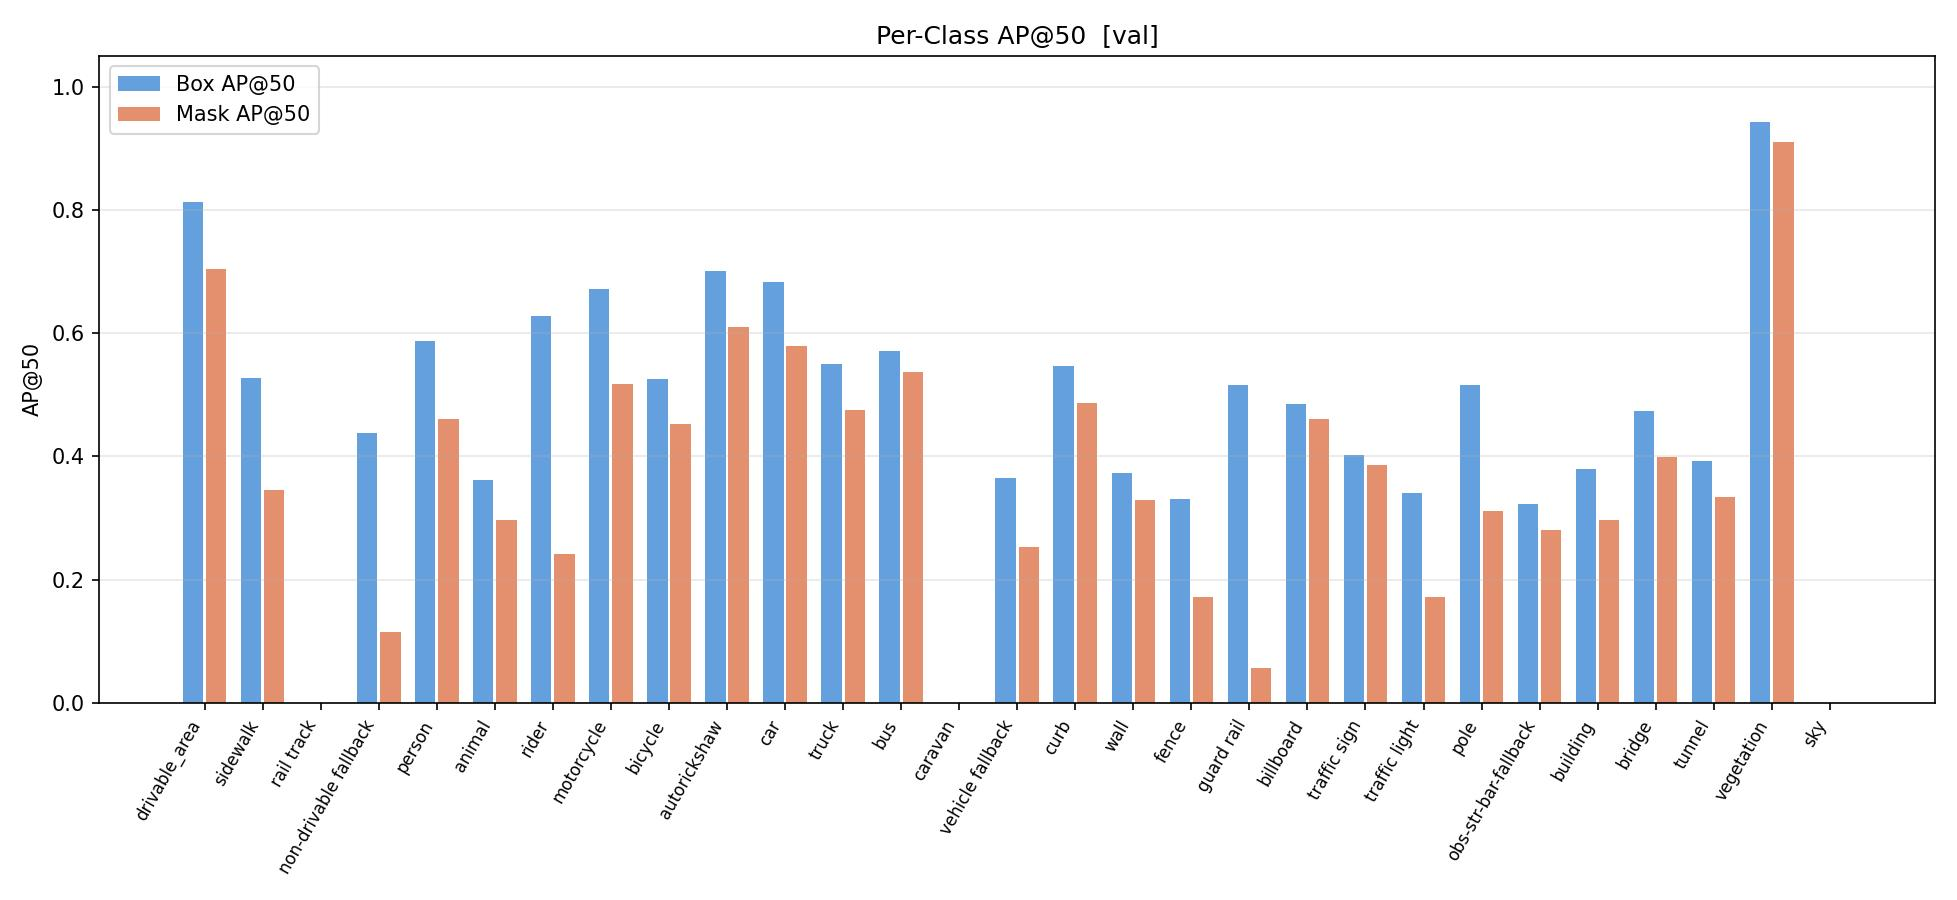

✅ Chart saved → eval_results\per_class_ap_val.jpg

✅ Evaluation outputs saved to: C:\Users\krris\Downloads\eval_results


In [9]:
# ════════════════════════════════════════════════════════════════════════════
#  CELL 5 — Evaluation & Metrics
# ════════════════════════════════════════════════════════════════════════════

# ✏️ Edit these two lines if needed:
EVAL_WEIGHTS = r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\best.pt"   # uses best.pt from training above
EVAL_SPLIT   = "val"               # "val" or "test"
EVAL_OUT_DIR = Path("eval_results")

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_classes(data_yaml):
    with open(data_yaml, "r") as f:
        return yaml.safe_load(f)["names"]


def run_yolo_val(weights, data_yaml, split, imgsz=640, batch=2):
    m = YOLO(weights)
    return m.val(
        data     = str(data_yaml),
        split    = split,
        imgsz    = imgsz,
        batch    = batch,
        device   = DEVICE,
        plots    = True,
        save_json= True,
        conf     = 0.25,
        iou      = 0.5,
        verbose  = True,
    )


def extract_per_class(metrics, class_names):
    rows = []
    try:
        box_ap50 = metrics.box.ap50
        box_ap   = metrics.box.ap
        box_p    = metrics.box.p
        box_r    = metrics.box.r
        seg_ap50 = metrics.seg.ap50
        seg_ap   = metrics.seg.ap
        for i in range(min(len(class_names), len(box_ap50))):
            f1 = 2 * box_p[i] * box_r[i] / (box_p[i] + box_r[i] + 1e-9)
            rows.append({
                "class_id":    i,
                "class_name":  class_names[i],
                "box_p":       round(float(box_p[i]),    4),
                "box_r":       round(float(box_r[i]),    4),
                "box_f1":      round(float(f1),          4),
                "box_ap50":    round(float(box_ap50[i]), 4),
                "box_ap50_95": round(float(box_ap[i]),   4),
                "mask_ap50":   round(float(seg_ap50[i]), 4),
                "mask_ap50_95":round(float(seg_ap[i]),   4),
            })
    except Exception as e:
        print(f"[WARN] Could not extract per-class metrics: {e}")
    return rows


def save_csvs(metrics, per_class_rows, out_dir, split):
    out_dir.mkdir(parents=True, exist_ok=True)
    summary = {
        "split":        split,
        "box_mAP50":    round(float(metrics.box.map50), 4),
        "box_mAP50_95": round(float(metrics.box.map),   4),
        "box_precision":round(float(metrics.box.mp),    4),
        "box_recall":   round(float(metrics.box.mr),    4),
        "mask_mAP50":   round(float(metrics.seg.map50), 4),
        "mask_mAP50_95":round(float(metrics.seg.map),   4),
    }
    with open(out_dir / f"eval_summary_{split}.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(summary.keys()))
        w.writeheader(); w.writerow(summary)
    if per_class_rows:
        with open(out_dir / f"eval_per_class_{split}.csv", "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(per_class_rows[0].keys()))
            w.writeheader(); w.writerows(per_class_rows)
    return summary


def print_report(summary, per_class_rows):
    print("\n" + "=" * 60)
    print("  EVALUATION RESULTS")
    print("=" * 60)
    for k, v in summary.items():
        print(f"  {k:<22} : {v}")
    print("=" * 60)
    if per_class_rows:
        print(f"\n  {'Class':<30} {'Box AP50':>9} {'Mask AP50':>10} {'F1':>7}")
        print("  " + "-" * 58)
        for r in sorted(per_class_rows, key=lambda x: -x["mask_ap50"]):
            print(f"  {r['class_name']:<30} {r['box_ap50']:>9.4f} {r['mask_ap50']:>10.4f} {r['box_f1']:>7.4f}")


def plot_per_class_ap(per_class_rows, out_dir, split):
    if not per_class_rows: return
    names  = [r["class_name"] for r in per_class_rows]
    ap_box = [r["box_ap50"]   for r in per_class_rows]
    ap_seg = [r["mask_ap50"]  for r in per_class_rows]
    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.45), 6))
    ax.bar(x - 0.2, ap_box, 0.35, label="Box AP@50",  color="#4A90D9", alpha=0.85)
    ax.bar(x + 0.2, ap_seg, 0.35, label="Mask AP@50", color="#E07B54", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
    ax.set_ylabel("AP@50")
    ax.set_title(f"Per-Class AP@50  [{split}]")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    chart_path = out_dir / f"per_class_ap_{split}.jpg"
    plt.savefig(chart_path, dpi=150)
    plt.close()
    # Show inline in Jupyter
    from IPython.display import Image, display
    display(Image(filename=str(chart_path)))
    print(f"✅ Chart saved → {chart_path}")


# ── RUN ───────────────────────────────────────────────────────────────────────
print(f"Evaluating : {EVAL_WEIGHTS}")
print(f"Split      : {EVAL_SPLIT}")

class_names = load_classes(DATA_YAML)
metrics     = run_yolo_val(EVAL_WEIGHTS, DATA_YAML, EVAL_SPLIT)

per_class_rows = extract_per_class(metrics, class_names)
summary        = save_csvs(metrics, per_class_rows, EVAL_OUT_DIR, EVAL_SPLIT)

print_report(summary, per_class_rows)
plot_per_class_ap(per_class_rows, EVAL_OUT_DIR, EVAL_SPLIT)

print(f"\n✅ Evaluation outputs saved to: {EVAL_OUT_DIR.resolve()}")

---
## Cell 6 — Inference / Demo
Runs the trained model on images or video and saves richly annotated output files.

**Output images show:**
- 🟢 **Drivable area** — lime green semi-transparent fill
- 🎨 **All other classes** — distinct colour per class
- 📦 **Bounding boxes** with class name + confidence score
- 📋 **Legend panel** (top-left)

> ✏️ Edit `INFER_SOURCE` in Cell 2 (or override it below) to point to your images/video.

In [10]:
# ════════════════════════════════════════════════════════════════════════════
#  CELL 6 — Inference / Demo
# ════════════════════════════════════════════════════════════════════════════

# ✏️ Override source / weights here if needed (or leave as-is to use Cell 2 config)
INF_WEIGHTS    = r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\best.pt"   # path to .pt weights
INF_SOURCE     = INFER_SOURCE        # image / folder / video file / "0" for webcam
INF_CONF       = INFER_CONF
INF_IOU        = INFER_IOU
INF_IMGSZ      = 640
INF_MASK_ALPHA = INFER_MASK_ALPHA
INF_OUT_DIR    = Path(INFER_OUT_DIR)
INF_SHOW_LEGEND= True
INF_MAX_DISPLAY= 4    # max images to display inline in notebook

# ── Colour palette ────────────────────────────────────────────────────────────
DRIVABLE_CLASS_NAME = "drivable_area"
DRIVABLE_BGR        = (50, 205, 50)    # lime green

_PALETTE = [
    (86,180,233),(230,159,0),(240,228,66),(204,121,167),(0,114,178),
    (213,94,0),(0,158,115),(255,127,14),(148,103,189),(140,86,75),
    (127,127,127),(188,189,34),(23,190,207),(31,119,180),(255,187,120),
    (174,199,232),(255,152,150),(197,176,213),(196,156,148),(247,182,210),
]

def get_colour(class_id, class_name):
    if class_name == DRIVABLE_CLASS_NAME:
        return DRIVABLE_BGR
    return _PALETTE[class_id % len(_PALETTE)]


# ── Load model ────────────────────────────────────────────────────────────────
def load_model_inf(weights):
    m = YOLO(weights)
    m.to(DEVICE)
    names = m.names
    drivable_id = next((cid for cid, cn in names.items()
                        if cn.lower() == DRIVABLE_CLASS_NAME), None)
    return m, names, drivable_id


# ── Render one frame ──────────────────────────────────────────────────────────
def render_frame(img_bgr, result, names, drivable_id,
                 mask_alpha=0.45, box_thickness=2,
                 font_scale=0.55, show_legend=True):
    out = img_bgr.copy()
    h, w = out.shape[:2]
    boxes = result.boxes
    masks = result.masks
    if boxes is None or len(boxes) == 0:
        return out

    # Draw masks
    if masks is not None:
        for box, mask in zip(boxes, masks.data.cpu().numpy()):
            cls_id   = int(box.cls[0].item())
            cls_name = names.get(cls_id, f"cls_{cls_id}")
            colour   = get_colour(cls_id, cls_name)
            msk      = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST) > 0.5
            alpha    = 0.55 if cls_id == drivable_id else mask_alpha
            out[msk] = (out[msk] * (1 - alpha) +
                        np.array(colour, dtype=np.float32) * alpha).astype(np.uint8)
            contours, _ = cv2.findContours(msk.astype(np.uint8),
                                           cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(out, contours, -1, colour, 1)

    # Draw boxes + labels
    for box in boxes:
        cls_id   = int(box.cls[0].item())
        cls_name = names.get(cls_id, f"cls_{cls_id}")
        conf     = float(box.conf[0].item())
        colour   = get_colour(cls_id, cls_name)
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cv2.rectangle(out, (x1, y1), (x2, y2), colour, box_thickness)
        label = f"{cls_name}  {conf:.2f}"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 1)
        ly1 = max(0, y1 - th - bl - 4)
        cv2.rectangle(out, (x1, ly1), (x1 + tw + 6, y1), colour, -1)
        tc = (0,0,0) if sum(colour) > 380 else (255,255,255)
        cv2.putText(out, label, (x1+3, y1-bl),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, tc, 1, cv2.LINE_AA)

    # Legend panel
    if show_legend and len(boxes) > 0:
        seen = {int(b.cls[0].item()): names.get(int(b.cls[0].item()), "") for b in boxes}
        lx, ly, sw, sh, pad = 10, 10, 14, 14, 4
        for cid, cname in seen.items():
            colour = get_colour(cid, cname)
            cv2.rectangle(out, (lx, ly), (lx+sw, ly+sh), colour, -1)
            cv2.putText(out, cname, (lx+sw+pad, ly+sh-2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1, cv2.LINE_AA)
            ly += sh + pad + 2
    return out


# ── Source iterator ───────────────────────────────────────────────────────────
IMAGE_EXTS = {".jpg",".jpeg",".png",".bmp",".tiff",".webp"}

def iter_source(source):
    src = str(source)
    p   = Path(src)
    if src.isdigit() or (p.is_file() and p.suffix.lower() in {".mp4",".avi",".mov",".mkv"}):
        cap = cv2.VideoCapture(int(src) if src.isdigit() else src)
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        while True:
            ret, frame = cap.read()
            if not ret: break
            yield frame, p.stem, True, fps
        cap.release(); return
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        img = cv2.imread(str(p))
        if img is not None: yield img, p.stem, False, None
        return
    if p.is_dir():
        for f in sorted(p.rglob("*")):
            if f.suffix.lower() in IMAGE_EXTS:
                img = cv2.imread(str(f))
                if img is not None: yield img, f.stem, False, None
        return
    print(f"[ERROR] Source not found: {source}")


# ── RUN ───────────────────────────────────────────────────────────────────────
from IPython.display import Image as IPyImage, display

INF_OUT_DIR.mkdir(parents=True, exist_ok=True)
inf_model, inf_names, inf_drivable_id = load_model_inf(INF_WEIGHTS)

print(f"\n{'='*60}")
print(f"  Inference")
print(f"{'='*60}")
print(f"  Weights       : {INF_WEIGHTS}")
print(f"  Source        : {INF_SOURCE}")
print(f"  Conf / IoU    : {INF_CONF} / {INF_IOU}")
print(f"  Output dir    : {INF_OUT_DIR}")
print(f"  Drivable id   : {inf_drivable_id} ({DRIVABLE_CLASS_NAME})")
print(f"{'='*60}\n")

video_writer = None
frame_idx    = 0
t_total      = 0.0
displayed    = 0

for frame_bgr, name, is_video, fps in iter_source(INF_SOURCE):
    t0 = time.time()

    results = inf_model.predict(
        source      = frame_bgr,
        conf        = INF_CONF,
        iou         = INF_IOU,
        imgsz       = INF_IMGSZ,
        device      = DEVICE,
        retina_masks= True,
        verbose     = False,
    )
    t_inf = time.time() - t0

    annotated = render_frame(
        frame_bgr, results[0], inf_names, inf_drivable_id,
        mask_alpha  = INF_MASK_ALPHA,
        show_legend = INF_SHOW_LEGEND,
    )

    # Inference time overlay
    cv2.putText(annotated, f"Inf: {t_inf*1000:.1f}ms",
                (annotated.shape[1]-160, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,200), 2, cv2.LINE_AA)

    if is_video:
        if video_writer is None:
            out_vid = INF_OUT_DIR / f"{name}_seg.mp4"
            video_writer = cv2.VideoWriter(
                str(out_vid), cv2.VideoWriter_fourcc(*"mp4v"),
                fps, (annotated.shape[1], annotated.shape[0])
            )
        video_writer.write(annotated)
    else:
        out_path = INF_OUT_DIR / f"{name}_seg.jpg"
        cv2.imwrite(str(out_path), annotated)
        n_det = len(results[0].boxes) if results[0].boxes else 0
        print(f"  [{frame_idx:>4}] {name:<40} det={n_det:>3}  {t_inf*1000:.1f}ms  → {out_path.name}")

        # Display first N images inline in the notebook
        if displayed < INF_MAX_DISPLAY:
            # Convert BGR→RGB for matplotlib
            rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            fig, ax = plt.subplots(1, 1, figsize=(12, 7))
            ax.imshow(rgb)
            ax.axis("off")
            ax.set_title(f"{name}  |  {n_det} detections  |  {t_inf*1000:.1f} ms",
                         fontsize=11)
            plt.tight_layout()
            plt.show()
            displayed += 1

    t_total  += t_inf
    frame_idx += 1

if video_writer is not None:
    video_writer.release()

avg_ms = (t_total / frame_idx * 1000) if frame_idx else 0
print(f"\n✅ Done — {frame_idx} frame(s) processed")
print(f"   Avg inference  : {avg_ms:.1f} ms/frame")
print(f"   Saved to       : {INF_OUT_DIR.resolve()}")


  Inference
  Weights       : C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\best.pt
  Source        : D:\Detectron\idd20kII\idd20kII\leftImg8bit\val
  Conf / IoU    : 0.25 / 0.45
  Output dir    : inference_outputs
  Drivable id   : 0 (drivable_area)

  [   0] frame0340_leftImg8bit                    det= 19  489.9ms  → frame0340_leftImg8bit_seg.jpg
  [   1] frame0671_leftImg8bit                    det= 20  40.7ms  → frame0671_leftImg8bit_seg.jpg
  [   2] frame0821_leftImg8bit                    det= 14  30.1ms  → frame0821_leftImg8bit_seg.jpg
  [   3] frame1047_leftImg8bit                    det=  5  28.3ms  → frame1047_leftImg8bit_seg.jpg
  [   4] frame1347_leftImg8bit                    det= 19  33.5ms  → frame1347_leftImg8bit_seg.jpg
  [   5] frame1527_leftImg8bit                    det= 11  49.8ms  → frame1527_leftImg8bit_seg.jpg
  [   6] frame1647_leftImg8bit                    det= 12  53.2ms  → frame1647_leftImg8bit_seg.jpg
  [   7]

In [14]:
%matplotlib inline

Detections : 38


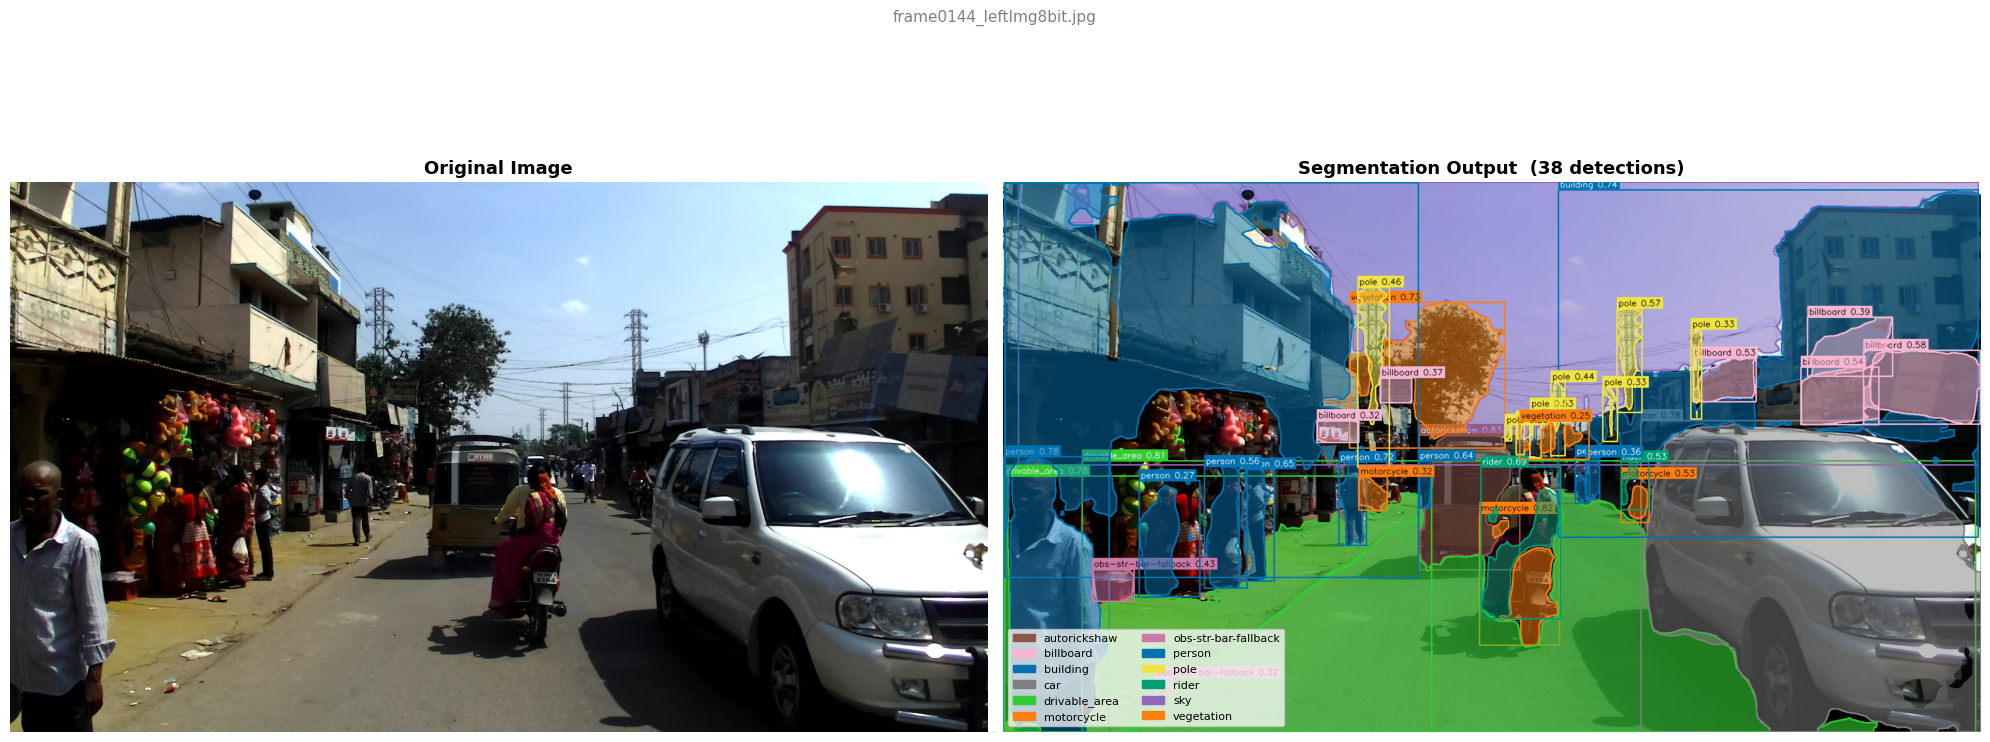

In [20]:
# ════════════════════════════════════════════════════════════════════════════
#  QUICK TEST — run inference on a single image and display inline
# ════════════════════════════════════════════════════════════════════════════
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2, numpy as np, torch
from ultralytics import YOLO

# ✏️ Set your test image path here
TEST_IMAGE   = r"D:\Detectron\idd20kII\idd20kII\leftImg8bit\val\272\frame0144_leftImg8bit.jpg"
#TEST_IMAGE = r"C:\Users\krris\Downloads\im2.jpg"
CONF_THRESH  = 0.25
IOU_THRESH   = 0.45
MASK_ALPHA   = 0.50

# ── Colour palette (BGR→RGB handled at display time) ─────────────────────────
DRIVABLE_NAME  = "drivable_area"
DRIVABLE_RGB   = (50, 205, 50)

_PALETTE_RGB = [
    (86,180,233),(230,159,0),(240,228,66),(204,121,167),(0,114,178),
    (213,94,0),(0,158,115),(255,127,14),(148,103,189),(140,86,75),
    (127,127,127),(188,189,34),(23,190,207),(31,119,180),(255,187,120),
    (174,199,232),(255,152,150),(197,176,213),(196,156,148),(247,182,210),
]

def get_rgb(class_id, class_name):
    if class_name == DRIVABLE_NAME:
        return DRIVABLE_RGB
    return _PALETTE_RGB[class_id % len(_PALETTE_RGB)]

# ── Load model ────────────────────────────────────────────────────────────────
inf_model = YOLO(r"C:\Users\krris\Downloads\runs\segment\runs\segment\idd_yolov8m_seg_20260328_135936\weights\best.pt")   # uses BEST_WEIGHTS from training cell
names     = inf_model.names           # {id: name}

# ── Load image ────────────────────────────────────────────────────────────────
img_bgr = cv2.imread(TEST_IMAGE)
assert img_bgr is not None, f"Could not read image: {TEST_IMAGE}"
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

# ── Run inference ─────────────────────────────────────────────────────────────
results = inf_model.predict(
    source       = img_bgr,
    conf         = CONF_THRESH,
    iou          = IOU_THRESH,
    imgsz        = 640,
    device       = DEVICE,
    retina_masks = True,
    verbose      = False,
)
result = results[0]
boxes  = result.boxes
masks  = result.masks

print(f"Detections : {len(boxes) if boxes else 0}")

# ── Overlay masks on a copy of the image ─────────────────────────────────────
overlay = img_rgb.copy().astype(np.float32)

legend_entries = {}   # class_name → rgb colour (for legend)

if masks is not None and boxes is not None:
    for box, mask in zip(boxes, masks.data.cpu().numpy()):
        cls_id   = int(box.cls[0].item())
        cls_name = names.get(cls_id, f"cls_{cls_id}")
        conf     = float(box.conf[0].item())
        colour   = get_rgb(cls_id, cls_name)
        legend_entries[cls_name] = colour

        # Resize mask to original image size
        msk = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5

        # Fill mask with colour
        alpha = 0.60 if cls_name == DRIVABLE_NAME else MASK_ALPHA
        overlay[msk] = (
            overlay[msk] * (1 - alpha) +
            np.array(colour, dtype=np.float32) * alpha
        )

        # Draw contour
        contours, _ = cv2.findContours(
            msk.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        # contours are drawn on uint8 copy then merged
        overlay_u8 = overlay.astype(np.uint8)
        cv2.drawContours(overlay_u8, contours, -1, colour, 2)
        overlay = overlay_u8.astype(np.float32)

        # Draw bounding box + label
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        overlay_u8 = overlay.astype(np.uint8)
        cv2.rectangle(overlay_u8, (x1, y1), (x2, y2), colour, 2)
        label = f"{cls_name} {conf:.2f}"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(overlay_u8, (x1, max(0, y1-th-bl-4)), (x1+tw+6, y1), colour, -1)
        tc = (0,0,0) if sum(colour) > 380 else (255,255,255)
        cv2.putText(overlay_u8, label, (x1+3, y1-bl),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, tc, 1, cv2.LINE_AA)
        overlay = overlay_u8.astype(np.float32)

final = overlay.astype(np.uint8)

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(final)
axes[1].set_title(f"Segmentation Output  ({len(boxes) if boxes else 0} detections)", 
                  fontsize=13, fontweight="bold")
axes[1].axis("off")

# Legend
patches = [
    mpatches.Patch(color=np.array(rgb)/255, label=name)
    for name, rgb in sorted(legend_entries.items())
]
if patches:
    axes[1].legend(
        handles=patches, loc="lower left", fontsize=8,
        framealpha=0.75, ncol=2, bbox_to_anchor=(0, 0)
    )

plt.suptitle(TEST_IMAGE.split("\\")[-1], fontsize=11, color="gray")
plt.tight_layout()
plt.show()